In [18]:
import numpy as np
import matplotlib.pyplot as plt
mu = 1.2150584270572e-2
mu_moon = 4.90279981e3
r_moon = 1738.1

In [19]:
# Example Save Code
# np.savez(
#     "3dorbit",
#     state = state,
#     time = time,
#     control = control,
#     time_c = time_c,
# )
# As long as the save file has state and time, this code will work. Edit the name to match the file of interest. Note that this code in its current state assumes that the state is in the nondimensionalized rotating frame.

file_name = "3dorbit"
path_modifier = "../Standard_Cycler_Generation/"
reference_name = path_modifier + file_name + ".npz"
orbit = np.load(reference_name)

In [20]:
def t_to_day(t):
    return t*27.321661/2/np.pi

def day_to_t(t):
    return t*2*np.pi/27.321661

def x_to_dist(x):
    return x*384400

def unit_convert(x):
    x_new = np.zeros(np.shape(x))
    for i in range(np.shape(x)[1]):
        x_new[0:3,i] = x_to_dist(x[0:3,i])
        x_new[3:6,i] = day_to_t(x_to_dist(x[3:6,i]))/86400
    return x_new

In [21]:
def delta_v(data, tgt_alt):
    state = data["state"]
    time = data["time"]
    tgt_radius = tgt_alt + r_moon
    xraw, yraw, zraw, vxraw, vyraw, vzraw = state
    xr, yr, zr, vxr, vyr, vzr = unit_convert(state)
    idx_mid = len(time)//2

    r1 = x_to_dist(xraw[idx_mid] - (1-mu))
    a_trns = (tgt_radius + r1)/2
    v1 = np.sqrt(mu_moon*(2/r1 - 1/a_trns))
    delta_v1 = v1 - vyr[idx_mid]

    v2 = np.sqrt(mu_moon*(2/tgt_radius - 1/a_trns))
    v2c = np.sqrt(mu_moon/tgt_radius)
    delta_v2 = v2c - v2

    delta_v_tot = np.abs(delta_v1) + np.abs(delta_v2)

    return delta_v_tot, delta_v1, delta_v2, r1

In [ ]:
test_alts = np.linspace(10, 690, 100)
delta_v_tot, delta_v1, delta_v2, r1 = delta_v(orbit, test_alts)

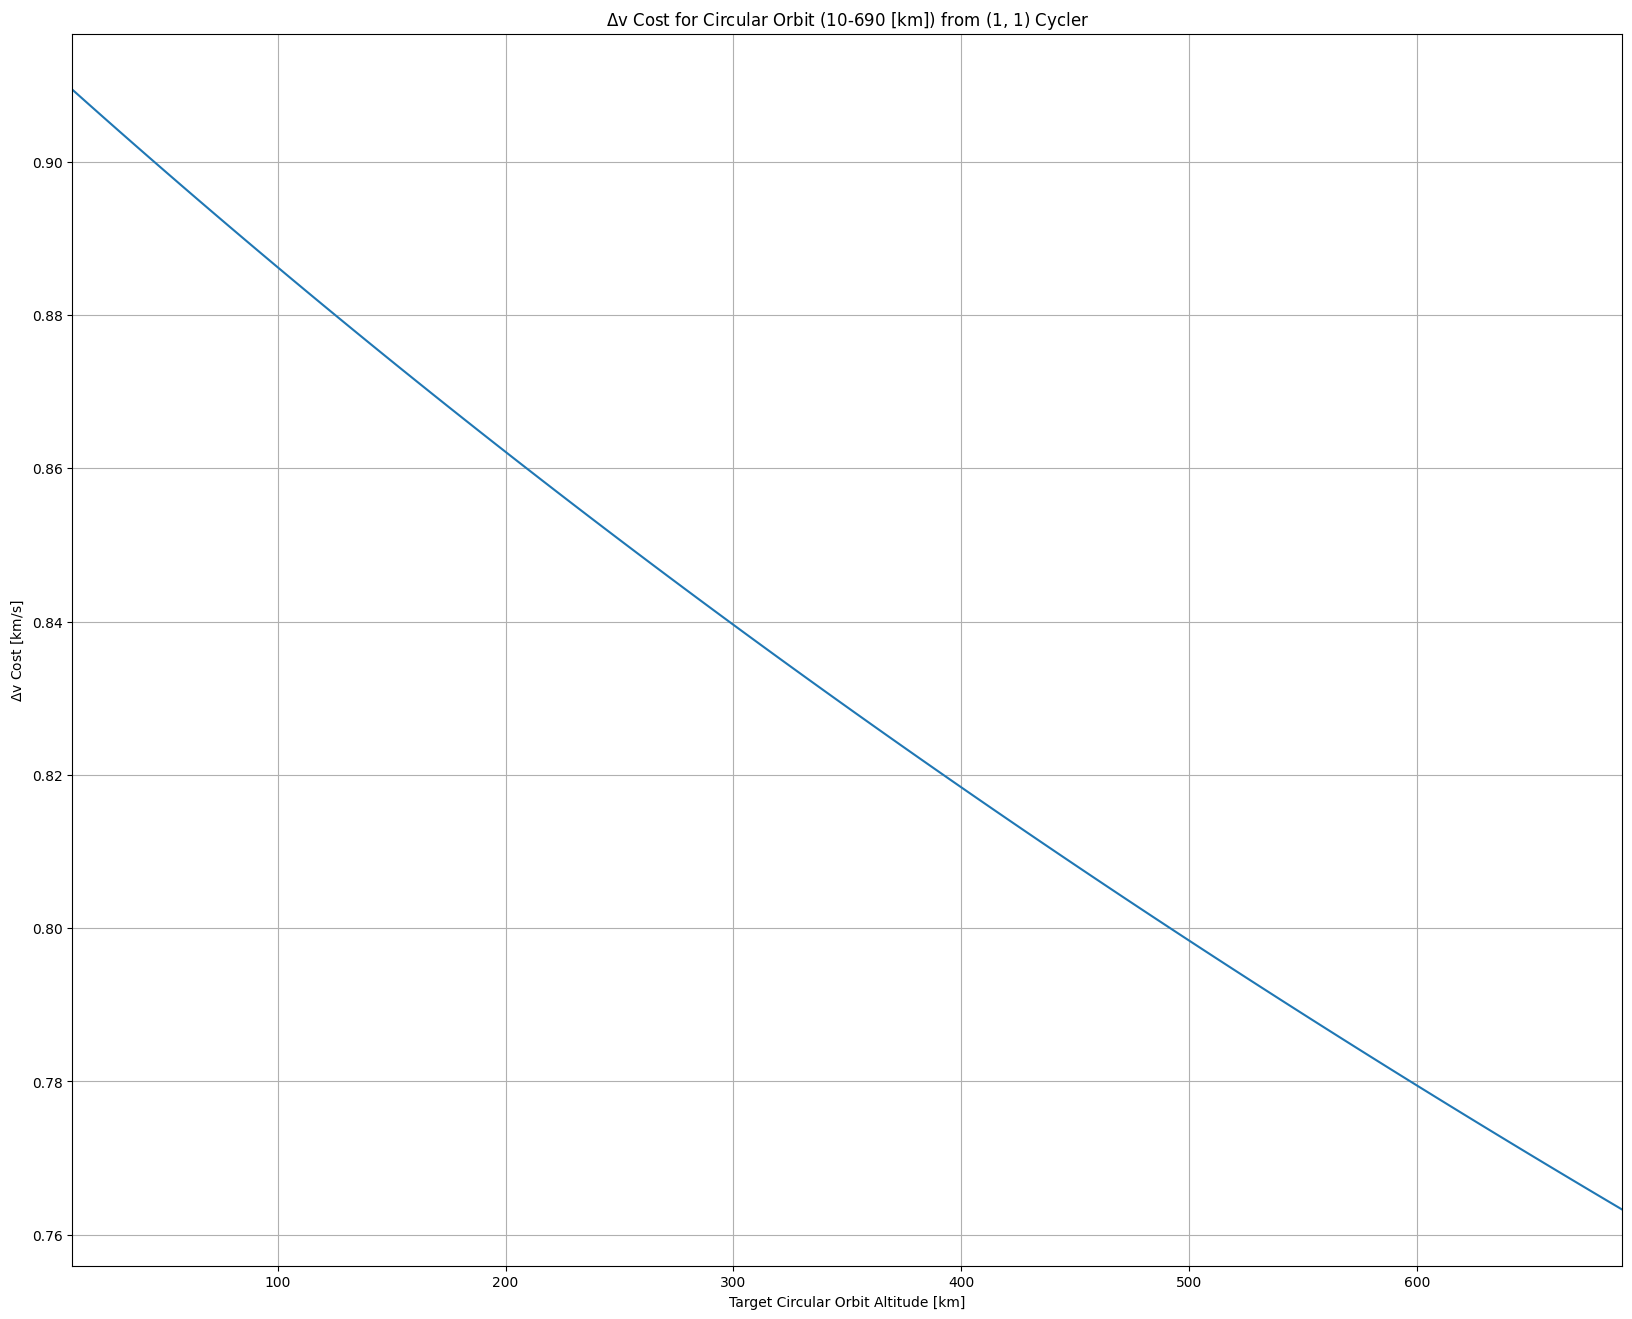

In [23]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(test_alts, delta_v_tot)
ax1.set_xlabel("Target Circular Orbit Altitude [km]")
ax1.set_ylabel(r"$\Delta$v Cost [km/s]")
ax1.set_title(r"$\Delta$v Cost for Circular Orbit (10-690 [km]) from (1, 1) Cycler")
ax1.set_xlim([min(test_alts), max(test_alts)])
ax1.grid(True)

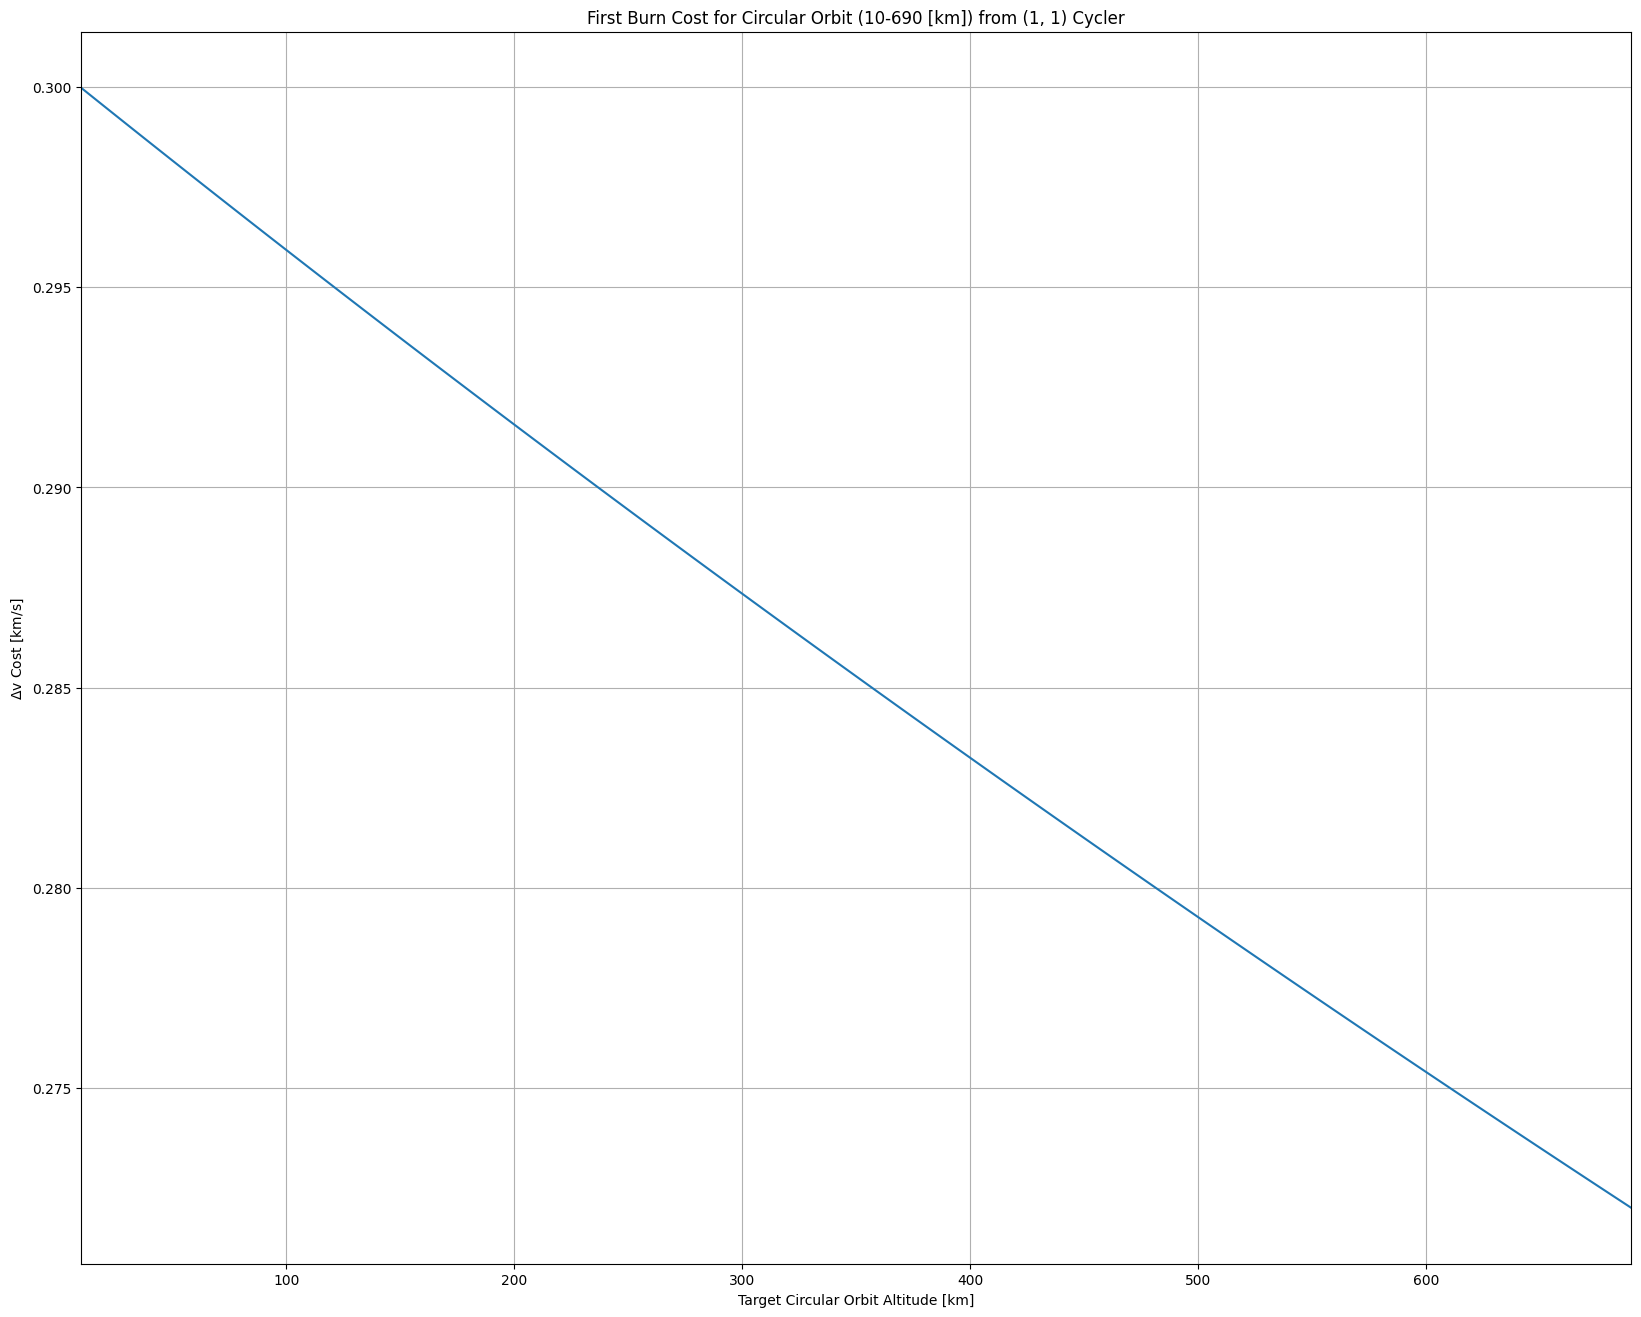

In [24]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(test_alts, np.abs(delta_v1))
ax1.set_xlabel("Target Circular Orbit Altitude [km]")
ax1.set_ylabel(r"$\Delta$v Cost [km/s]")
ax1.set_title(r"First Burn Cost for Circular Orbit (10-690 [km]) from (1, 1) Cycler")
ax1.set_xlim([min(test_alts), max(test_alts)])
ax1.grid(True)

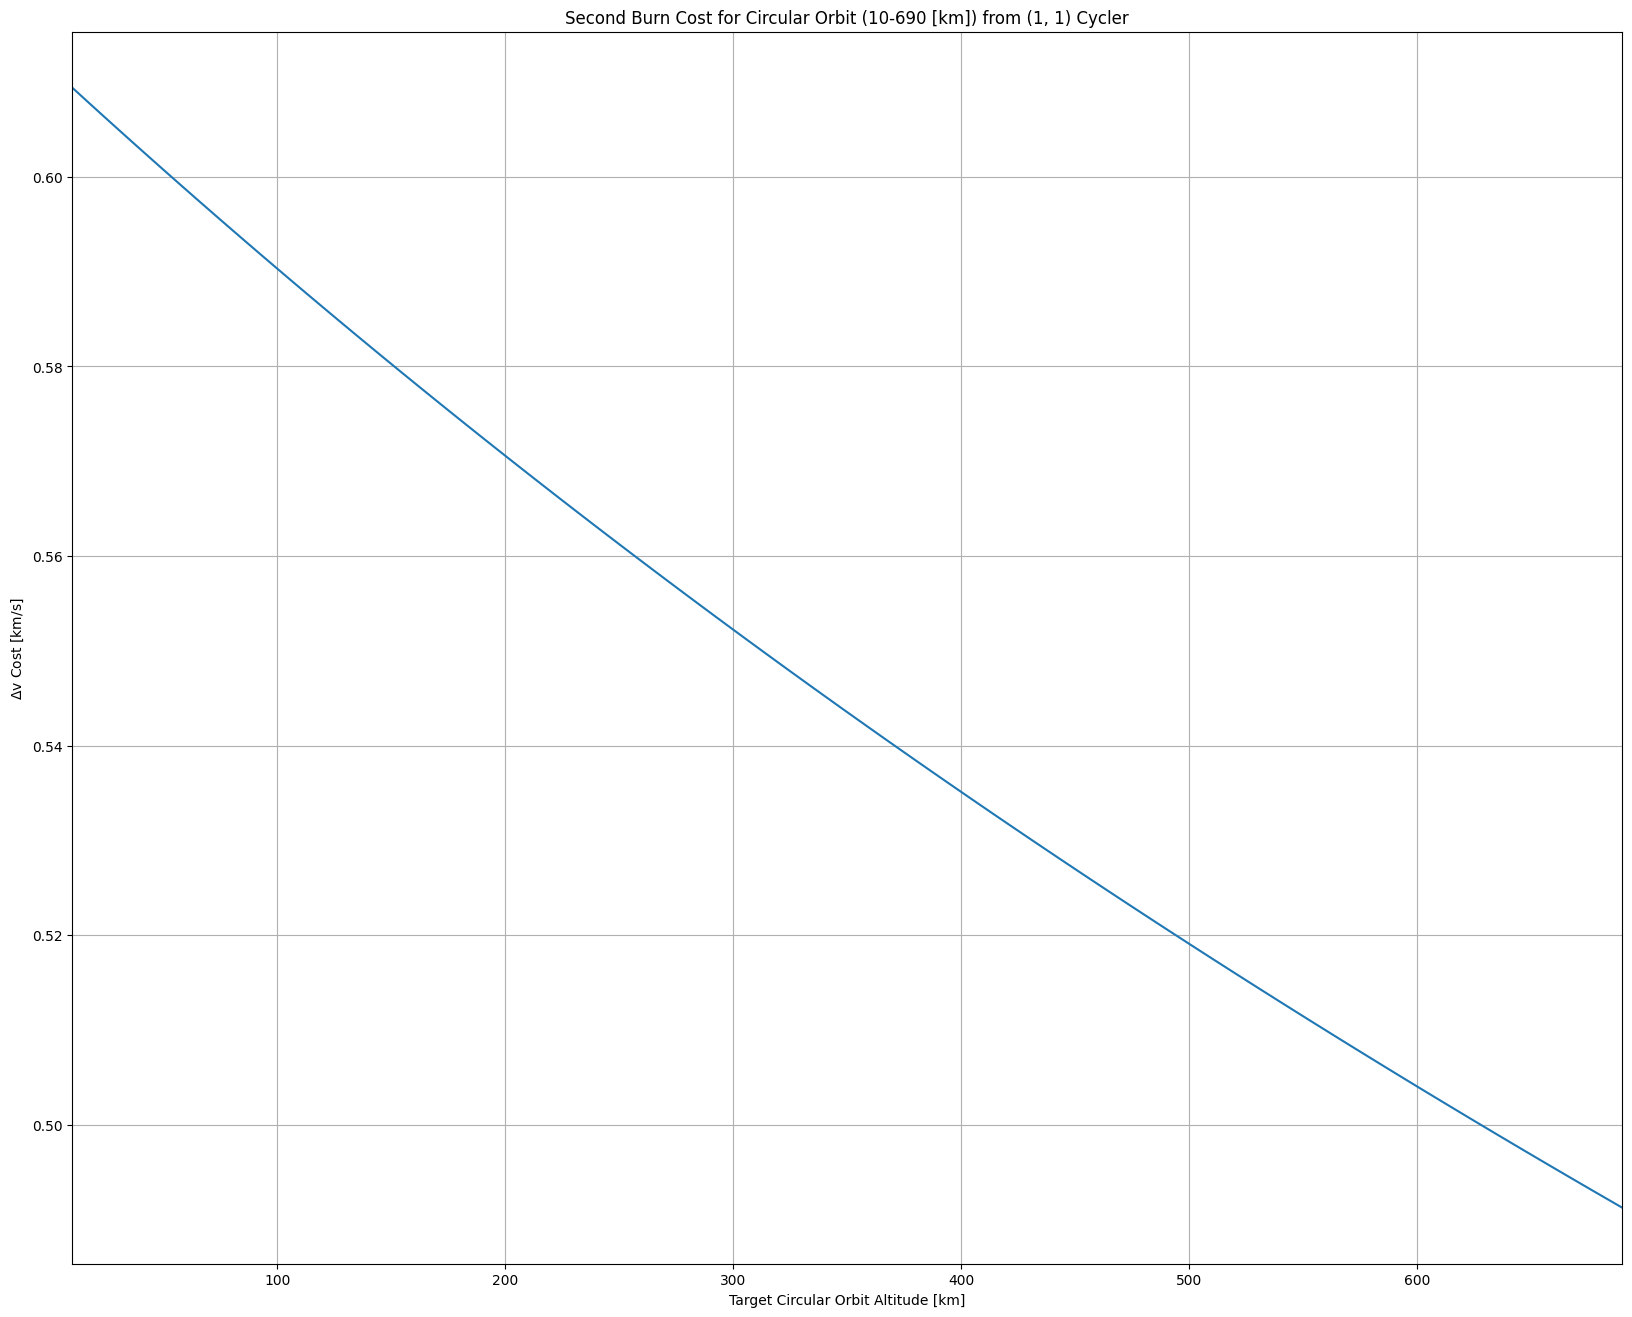

In [25]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(test_alts, np.abs(delta_v2))
ax1.set_xlabel("Target Circular Orbit Altitude [km]")
ax1.set_ylabel(r"$\Delta$v Cost [km/s]")
ax1.set_title(r"Second Burn Cost for Circular Orbit (10-690 [km]) from (1, 1) Cycler")
ax1.set_xlim([min(test_alts), max(test_alts)])
ax1.grid(True)